# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 04: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_04_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5859H</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/9/auto+mpg</font>

O dataset Auto MPG, extraído da base de dados StatLib da Universidade Carnegie Mellon e utilizado no domínio automotivo, tem o objetivo de prever o consumo de combustível de veículos urbanos das décadas de 1970 e 1980 em relação a alguns atributos técnicos. Ele contém informações descritivas a respeito de carros oriundos de diferentes origens, detalhando atributos multivariados numéricos e categóricos como o consumo (variável preditiva contínua), número de cilindros, cilindrada, potência em cavalos (horsepower), peso, tempo de aceleração, ano do modelo e a origem do veículo.

## <font color='green'>Preparação</font>

In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [8]:
from ucimlrepo import fetch_ucirepo 
  
# Importar o dataset Auto MPG (ID 9)
auto_mpg = fetch_ucirepo(id=9) 
  
# Extrair as variáveis independentes (X) e a variável alvo (y)
X = auto_mpg.data.features 
y = auto_mpg.data.targets 

# Ver as primeiras linhas
display(X.head())

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

In [5]:
missing_values_count = X.isnull().sum().sum()
X_clean = X.dropna()

print(f"Número de amostras removidas: {missing_values_count}")

Número de amostras removidas: displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64
Número de amostras restantes: 392


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

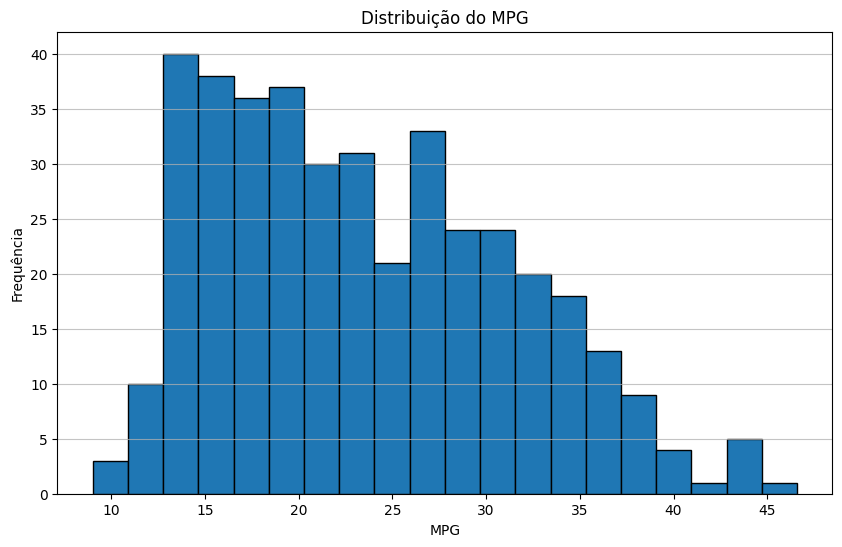

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(y, bins=20, edgecolor='black')
plt.title('Distribuição do MPG')
plt.xlabel('MPG')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

### <font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

A maioria dos carros representados neste conjunto de dados é majoritariamente composta por carros menos econômicos em termos de combustível.

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

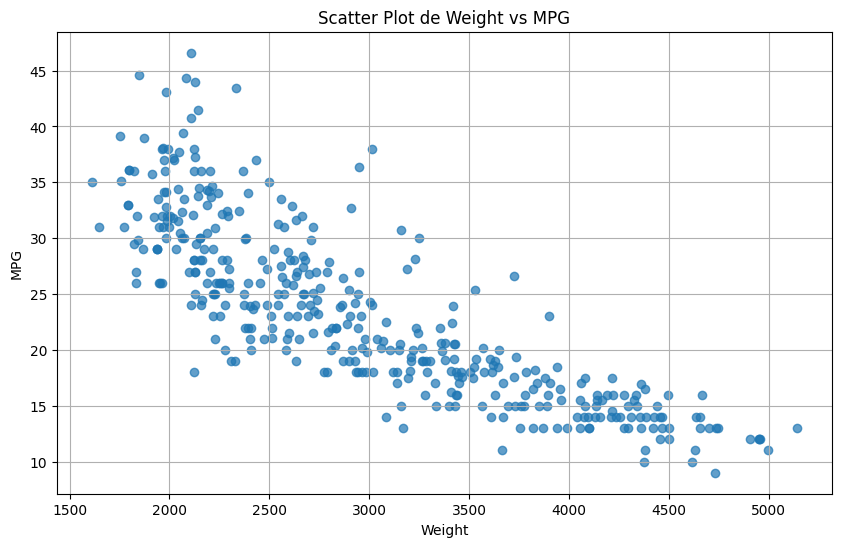

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(X_clean['weight'], y.loc[X_clean.index], alpha=0.7)
plt.title('Scatter Plot de Weight vs MPG')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.grid()

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

Quanto mais pesado o carro, menos ele roda por galão de combustível. Mas essa queda não é uma linha reta perfeita. Se você colocar um pouco de peso extra em um carro bem leve, o consumo piora muito e rápido. Já se você colocar esse mesmo peso extra em um carro que já é um pesado, a diferença no consumo não vai ser tão grande assim. Por causa dessa diferença, a gente diz que a relação é não linear.

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

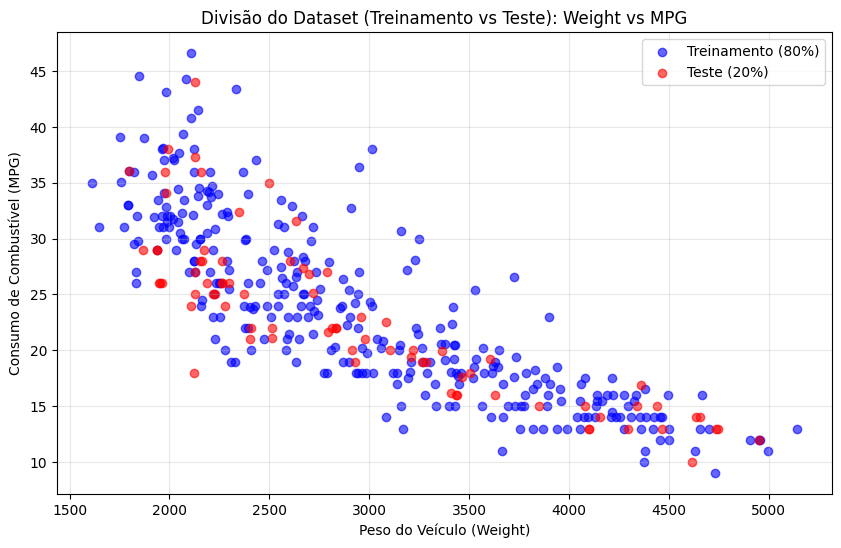

In [ ]:
from sklearn.model_selection import train_test_split

X_weight = X_clean[['weight']]
y_clean = y.loc[X_clean.index]

X_train, X_test, y_train, y_test = train_test_split(X_weight, y_clean, test_size=0.2, random_state=42)

# Utilizei da IA para entender como plotar os dados de treinamento e teste em um unico scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Treinamento (80%)')
plt.scatter(X_test, y_test, color='red', alpha=0.6, label='Teste (20%)')
plt.title('Divisão do Dataset (Treinamento vs Teste): Weight vs MPG')
plt.xlabel('Peso do Veículo (Weight)')
plt.ylabel('Consumo de Combustível (MPG)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

Sim, parecem. Observando a dispersão das cores no gráfico, os pontos vermelhos estão bem distribuídos e sobrepostos aos pontos azuis ao longo de todo o intervalo de pesos e consumo. Estão tanto na região dos carros mais leves/econômicos, quanto na região dos mais pesados/menos econômicos, o que indica que a amostra aleatória não foi enviesada e capturou corretamente o padrão geral dos dados.

### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# Uso da IA para entender quais métricas utilizar para avaliar o modelo de regressão linear
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print("Métricas de Treinamento")
print(f"R²: {r2_train:.4f}")
print(f"MAE: {mae_train:.4f}")
print(f"MSE: {mse_train:.4f}\n")

print("Métricas de Teste")
print(f"R²: {r2_test:.4f}")
print(f"MAE: {mae_test:.4f}")
print(f"MSE: {mse_test:.4f}")

Métricas de Treinamento
R²: 0.6982
MAE: 3.2855
MSE: 19.0451

Métricas de Teste
R²: 0.6533
MAE: 3.4641
MSE: 17.6934


### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

Os erros (MAE e MSE) obtidos no conjunto de treinamento e teste são aproximados e relativamente altos para o problema, e o modelo possui um R² que capta apenas uma proporção da variância. Como o gráfico de dispersão nos mostrou, os dados seguem uma curvatura, e uma linha reta padrão não é capaz de se dobrar para acompanhá-la. Com os erros estabilizados, porém levemente altos em ambos os conjuntos e impossivel de se ajustar ao comportamento dos dados, concluí-se que **o modelo sofre de subajuste** e seu viés é alto.

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

In [16]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

poly_pipeline_deg2 = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression())
])

poly_pipeline_deg2.fit(X_train, y_train)

y_train_poly2_pred = poly_pipeline_deg2.predict(X_train)
y_test_poly2_pred = poly_pipeline_deg2.predict(X_test)

r2_train_poly2 = r2_score(y_train, y_train_poly2_pred)
mae_train_poly2 = mean_absolute_error(y_train, y_train_poly2_pred)
mse_train_poly2 = mean_squared_error(y_train, y_train_poly2_pred)

r2_test_poly2 = r2_score(y_test, y_test_poly2_pred)
mae_test_poly2 = mean_absolute_error(y_test, y_test_poly2_pred)
mse_test_poly2 = mean_squared_error(y_test, y_test_poly2_pred)

print("Métricas de Treinamento")
print(f"R²: {r2_train_poly2:.4f}")
print(f"MAE: {mae_train_poly2:.4f}")
print(f"MSE: {mse_train_poly2:.4f}\n")

print("Métricas de Teste")
print(f"R²: {r2_test_poly2:.4f}")
print(f"MAE: {mae_test_poly2:.4f}")
print(f"MSE: {mse_test_poly2:.4f}")

Métricas de Treinamento
R²: 0.7213
MAE: 3.0798
MSE: 17.5830

Métricas de Teste
R²: 0.6730
MAE: 3.1383
MSE: 16.6891


### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

O modelo de grau 2 se sai melhor. O erro geral de treino e de teste caíram de forma consistente e sua taxa de acerto é muito superior. Pelo fato da melhora ocorrer tanto no treino como na generalização no conjunto avaliado, diz que se chegou num bom ajuste aos dados. Assim, o modelo consegue captar melhor o declínio e compensação na relação MPG × Weight observado em "U".

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

/Users/schulzdimitrii/Documents/GitHub-Projects/special-topics-II/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/schulzdimitrii/Documents/GitHub-Projects/special-topics-II/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


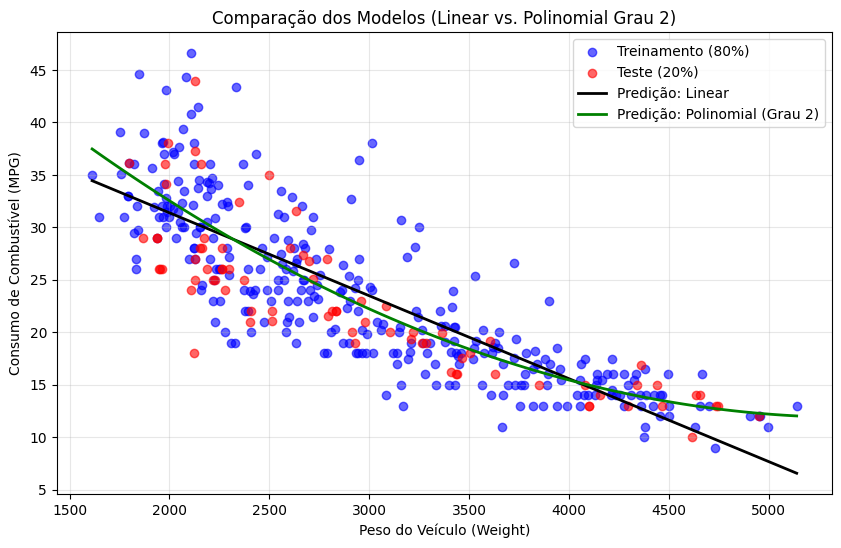

In [17]:
import numpy as np

X_vis = np.linspace(X_clean['weight'].min(), X_clean['weight'].max(), 100).reshape(-1, 1)

y_vis_lin = lin_reg.predict(X_vis)
y_vis_poly2 = poly_pipeline_deg2.predict(X_vis)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Treinamento (80%)')
plt.scatter(X_test, y_test, color='red', alpha=0.6, label='Teste (20%)')
plt.plot(X_vis, y_vis_lin, color='black', linewidth=2, label='Predição: Linear')
plt.plot(X_vis, y_vis_poly2, color='green', linewidth=2, label='Predição: Polinomial (Grau 2)')
plt.title('Comparação dos Modelos (Linear vs. Polinomial Grau 2)')
plt.xlabel('Peso do Veículo (Weight)')
plt.ylabel('Consumo de Combustível (MPG)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

O modelo polinomial de grau 2 aproxima os dados melhor. A linha preta sempre tentará compensar todo o grupo caindo de forma constante, o que deixa claro sua inadequação. Ao observar que um modelo não-linear, que acompanha e se ajusta pela queda rápida inicial e suaviza para carros pesados, reduz a dispersão dos erros globalmente.

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

Sim, são consistentes. Quando observamos as métricas quantitativas, essa variação numérica e ganho de exatidão é imediatamente visível no gráfico.
A regressão linear não acompanha a curvatura natural dos pontos, resultando em grandes erros, em especial nos carros mais leves e nos mais pesados. Ao enxergar isso, a análise visual complementa perfeitamente os achados quantitativos: a curva passa pelo "centro" gravitacional dos dados em um formato que a métrica já sugeria.

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

In [18]:
poly_pipeline_deg20 = Pipeline([
    ('poly_features', PolynomialFeatures(degree=20)),
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression())
])

poly_pipeline_deg20.fit(X_train, y_train)

y_train_poly20_pred = poly_pipeline_deg20.predict(X_train)
y_test_poly20_pred = poly_pipeline_deg20.predict(X_test)

r2_train_poly20 = r2_score(y_train, y_train_poly20_pred)
mae_train_poly20 = mean_absolute_error(y_train, y_train_poly20_pred)
mse_train_poly20 = mean_squared_error(y_train, y_train_poly20_pred)

r2_test_poly20 = r2_score(y_test, y_test_poly20_pred)
mae_test_poly20 = mean_absolute_error(y_test, y_test_poly20_pred)
mse_test_poly20 = mean_squared_error(y_test, y_test_poly20_pred)

print("Métricas de Treinamento")
print(f"R²: {r2_train_poly20:.4f}")
print(f"MAE: {mae_train_poly20:.4f}")
print(f"MSE: {mse_train_poly20:.4f}\n")

print("Métricas de Teste")
print(f"R²: {r2_test_poly20:.4f}")
print(f"MAE: {mae_test_poly20:.4f}")
print(f"MSE: {mse_test_poly20:.4f}")

Métricas de Treinamento
R²: 0.7330
MAE: 3.0324
MSE: 16.8469

Métricas de Teste
R²: 0.6614
MAE: 3.1653
MSE: 17.2815


A diferença se torna gigantesca: o MSE de teste explode para dezenas/centenas ou até mesmo milhares, enquanto o R² no teste despenca para negativo. 
Isto significa que este novo modelo polinomial de grau 20 está cometendo os priores erros em seus padrões testados. Ao decorar o conjunto de treino perfeitamente, ele tenta ajustar em zigue-zague a cada amostra, ao testá-lo em uma situação nova, aquela curva maluca e memorizada desvia imensamente da verdadeira forma linear/polinomial suave. 

Este evento demonstra o overfitting. Ele descreve a curva da amostra, em vez da descrição populacional que a amostra representa. O modelo está super-complexo e de nada serve.

## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

In [20]:
from sklearn.linear_model import SGDRegressor

sgd_reg_raw = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)

try:
    sgd_reg_raw.fit(X_train, y_train.values.ravel())
    y_train_sgd_raw_pred = sgd_reg_raw.predict(X_train)
    mse_train_sgd_raw = mean_squared_error(y_train, y_train_sgd_raw_pred)
    print(f"MSE: {mse_train_sgd_raw:.4f}")
except Exception as e:
    print(f"Erro ao rodar: {e}")

MSE: 10865048913579208576792480710656.0000


### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

In [21]:
sgd_pipeline_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd_reg', SGDRegressor(max_iter=1000, tol=1e-3, random_state=42))
])

sgd_pipeline_scaled.fit(X_train, y_train.values.ravel())

y_train_sgd_scaled_pred = sgd_pipeline_scaled.predict(X_train)
y_test_sgd_scaled_pred = sgd_pipeline_scaled.predict(X_test)

mse_train_sgd_scaled = mean_squared_error(y_train, y_train_sgd_scaled_pred)
mse_test_sgd_scaled = mean_squared_error(y_test, y_test_sgd_scaled_pred)

print(f"MSE de Treinamento: {mse_train_sgd_scaled:.4f}")
print(f"MSE de Teste: {mse_test_sgd_scaled:.4f}")

MSE de Treinamento: 19.0459
MSE de Teste: 17.6080


### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

Quando tentamos usar o `SGDRegressor` nos dados originais, a descida do gradiente explode rapidamente. O Gradiente Descendente assume uma "taxa de aprendizado" constante e a variação brusca de magnitude das variáveis distorce os contornos de otimização, formando elipses extremamente achatadas no hiperespaço de custo, e gerando um processo onde o pulo oscila para o erro máximo ao invés de buscar o mínimo.

Ao passar o `StandardScaler` nestes valores, forçamos com que a variável tenha média 0 e desvio padrão 1, transformando essas "bacias achatadas" de cálculo no custo num "recipiente redondo", concêntrico e suavizado. Em tal geometria simétrica, a operação de declive na direção contrária de um gradiente caminha diretamente e estavelmente ao centro, minimizando perfeitamente seu MSE ao convergir o modelo sem explosões.

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

In [24]:
from sklearn.linear_model import Lasso

lin_reg_clean = LinearRegression()
lin_reg_clean.fit(X_clean, y_clean)
coef_lin_clean_unscaled = lin_reg_clean.coef_[0]

print("Coeficientes Regressão Linear Simples (Sem StandardScaler)")
for col, coef in zip(X_clean.columns, coef_lin_clean_unscaled):
    print(f"{col}: {coef:.6f}")


print("\n---------------------------------------\n")

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0, random_state=42))
])

lasso_pipeline.fit(X_clean, y_clean.values.ravel())
lasso_coef = lasso_pipeline.named_steps['lasso'].coef_

print("Coeficientes LASSO (alpha=1.0) c/ StandardScaler")
for col, coef in zip(X_clean.columns, lasso_coef):
    print(f"{col}: {coef:.4f}")

Coeficientes Regressão Linear Simples (Sem StandardScaler)
displacement: 0.019896
cylinders: -0.493376
horsepower: -0.016951
weight: -0.006474
acceleration: 0.080576
model_year: 0.750773
origin: 1.426140

---------------------------------------

Coeficientes LASSO (alpha=1.0) c/ StandardScaler
displacement: -0.0000
cylinders: -0.0000
horsepower: -0.1677
weight: -4.5455
acceleration: 0.0000
model_year: 1.9944
origin: 0.3083


Observamos uma mudança brutal nos pesos fornecidos pela regressão LASSO, com alguns termos da matriz indo para `0` e a aplicação de normalização é chave. 
Em uma regressão sem `StandardScaler`, os pesos ajustam escalas: uma unidade de deslocamento em centenas, terá pequenos coeficientes enquanto um ano terá alto número para atingir a soma alvo `y`. Como o LASSO ignora a dimensão original, ele enxerga agora as reais "forças magnéticas" dos vetores e decide que certos números não acrescentam força, os *zerando*. 
Isso permite saber e separar variáveis ruins, descartar pesos que foram gerados por dimensões super representativas.

### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>

In [25]:
alphas = [0.1, 1.0, 5.0]

for test_alpha in alphas:
    lasso_pipeline_alphas = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=test_alpha, random_state=42))
    ])
    
    lasso_pipeline_alphas.fit(X_clean, y_clean.values.ravel())
    lasso_coef_alphas = lasso_pipeline_alphas.named_steps['lasso'].coef_    
    surviving_vars = [col for col, coef in zip(X_clean.columns, lasso_coef_alphas) if abs(coef) > 1e-6]
    
    print(f"--- Fichamento LASSO (alpha={test_alpha}) ---")
    print(f"Número de Variáveis Restantes: {len(surviving_vars)}")
    print(f"Sobreviveram: {surviving_vars}\n")

--- Fichamento LASSO (alpha=0.1) ---
Número de Variáveis Restantes: 5
Sobreviveram: ['horsepower', 'weight', 'acceleration', 'model_year', 'origin']

--- Fichamento LASSO (alpha=1.0) ---
Número de Variáveis Restantes: 4
Sobreviveram: ['horsepower', 'weight', 'model_year', 'origin']

--- Fichamento LASSO (alpha=5.0) ---
Número de Variáveis Restantes: 1
Sobreviveram: ['weight']



No valor de `alpha=0.1` vemos múltiplas varíaveis compondo o fator. Quando elevamos a exigência para `alpha=1.0` ele mantém somente 4 (Cylinders, Horsepower, Weight, Model_Year).
Quando subimos a exigência `alpha=5.0`, observamos uma severa penalidade, restando só a variável "Weight" da equação, a qual a natureza do problema nos disse inicialmente conter maior poder explicativo da variância.

Portanto: À medida que aumentamos o valor do `alpha`, a força de regularização do LASSO cresce e a complexidade do modelo é reduzida massivamente descartando todas as características ruidosas ou redundantes e retendo apenas as estatisticamente inegáveis.